# ORACLE, PubMedQA EDA
## Biomedical QA Domain

**Dataset:** PubMedQA, Jin et al. (2019), EMNLP  
**Records:** 1,000 expert-annotated (labeled split)  
**Labels:** yes / no / maybe  
**Domain:** Biomedical QA, English  

**Key facts:**
- Questions answerable from provided PubMed abstracts
- Yes-biased (55.2%), most biomedical hypotheses confirmed
- Research-facing questions, not patient-facing
- ORACLE uses PubMedQA to establish retrieval baseline

**Limitation:** Research vocabulary, ORACLE evaluates patient accessibility separately via Consumer Health QA and PLABA.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pubmedqa_loader import load_pubmedqa_labeled

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

LABEL_COLORS = {'yes':'#5cb85c', 'no':'#d9534f', 'maybe':'#f0ad4e'}
print('Imports complete')

Imports complete


In [2]:
labeled = load_pubmedqa_labeled()
df = labeled['data']
labels = labeled['labels']
df['label'] = labels.values
df['q_len'] = df['question'].astype(str).str.len()
df['ctx_len'] = df['context'].apply(lambda x: sum(len(c) for c in x['contexts']))
df['n_ctx'] = df['context'].apply(lambda x: len(x['contexts']))
df['ans_len'] = df['long_answer'].astype(str).str.len()
df['meshes'] = df['context'].apply(lambda x: list(x['meshes']) if len(x['meshes'])>0 else [])
df['reasoning_req'] = df['context'].apply(lambda x: ''.join(x['reasoning_required_pred']))
df['reasoning_free'] = df['context'].apply(lambda x: ''.join(x['reasoning_free_pred']))

print(f'Shape: {df.shape}')
print(f'Labels: {df["label"].value_counts().to_dict()}')

Loading PubMedQA labeled split...


  Records:     1,000
  Label dist:  {'yes': 552, 'no': 338, 'maybe': 110}
Shape: (1000, 12)
Labels: {'yes': 552, 'no': 338, 'maybe': 110}


## 1. Label Distribution, Yes/No/Maybe

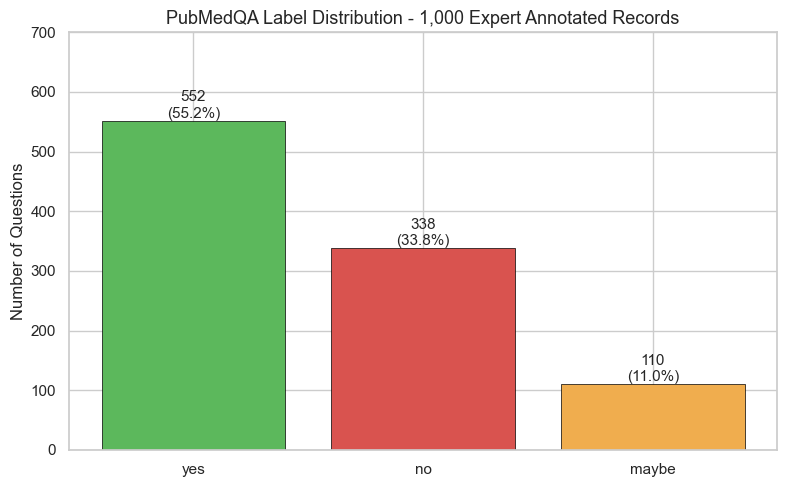

Yes-biased (55.2%), most biomedical hypotheses confirmed in literature


In [3]:
label_counts = df['label'].value_counts()
labels_order = ['yes','no','maybe']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(labels_order, [label_counts[l] for l in labels_order],
              color=[LABEL_COLORS[l] for l in labels_order], edgecolor='black', linewidth=0.5)
for bar, label in zip(bars, labels_order):
    val = label_counts[label]
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('PubMedQA Label Distribution - 1,000 Expert Annotated Records', fontsize=13)
ax.set_ylabel('Number of Questions')
ax.set_ylim(0, 700)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Yes-biased (55.2%), most biomedical hypotheses confirmed in literature')

## 2. Question Length by Label

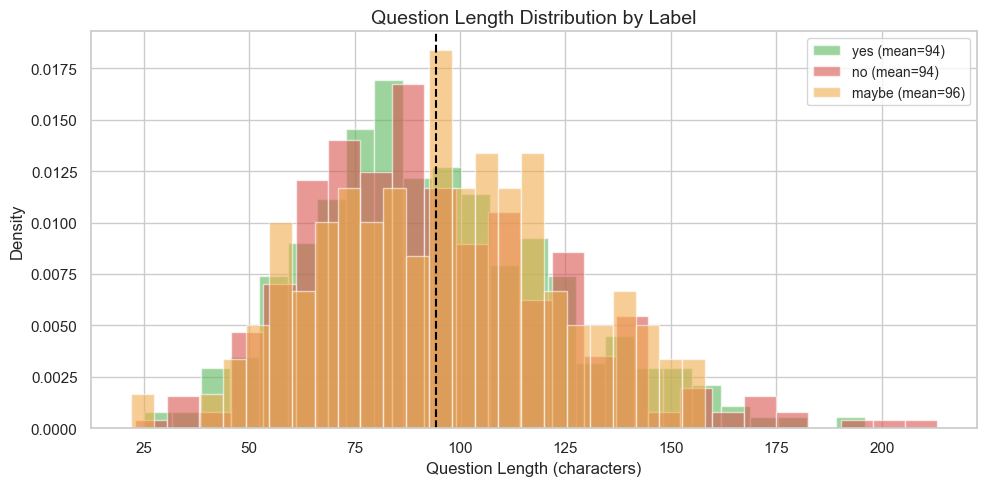

Mean question length: 94 chars, consistent across labels


In [4]:
fig, ax = plt.subplots(figsize=(10,5))
for label in ['yes','no','maybe']:
    subset = df[df['label']==label]['q_len']
    ax.hist(subset, bins=25, alpha=0.6, color=LABEL_COLORS[label],
            label=f'{label} (mean={subset.mean():.0f})', density=True)
ax.set_title('Question Length Distribution by Label', fontsize=14)
ax.set_xlabel('Question Length (characters)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
ax.axvline(x=df['q_len'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["q_len"].mean():.0f})')
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_question_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean question length: {df["q_len"].mean():.0f} chars, consistent across labels')

## 3. Context Length Distribution

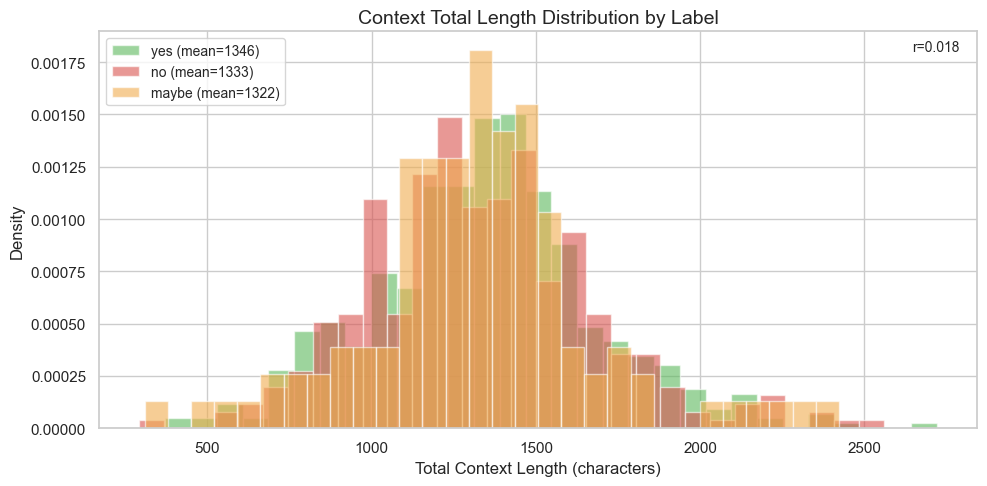

Near-zero correlation (r=0.018), context length not predictive of label


In [5]:
fig, ax = plt.subplots(figsize=(10,5))
for label in ['yes','no','maybe']:
    subset = df[df['label']==label]['ctx_len']
    ax.hist(subset, bins=30, alpha=0.6, color=LABEL_COLORS[label],
            label=f'{label} (mean={subset.mean():.0f})', density=True)
ax.set_title('Context Total Length Distribution by Label', fontsize=14)
ax.set_xlabel('Total Context Length (characters)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
corr = df['ctx_len'].corr(df['label'].map({'yes':1,'no':0,'maybe':0.5}))
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_context_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Near-zero correlation (r={corr:.3f}), context length not predictive of label')

## 4. Number of Contexts per Question

72% of questions have exactly 3 context paragraphs, standard PubMedQA format.

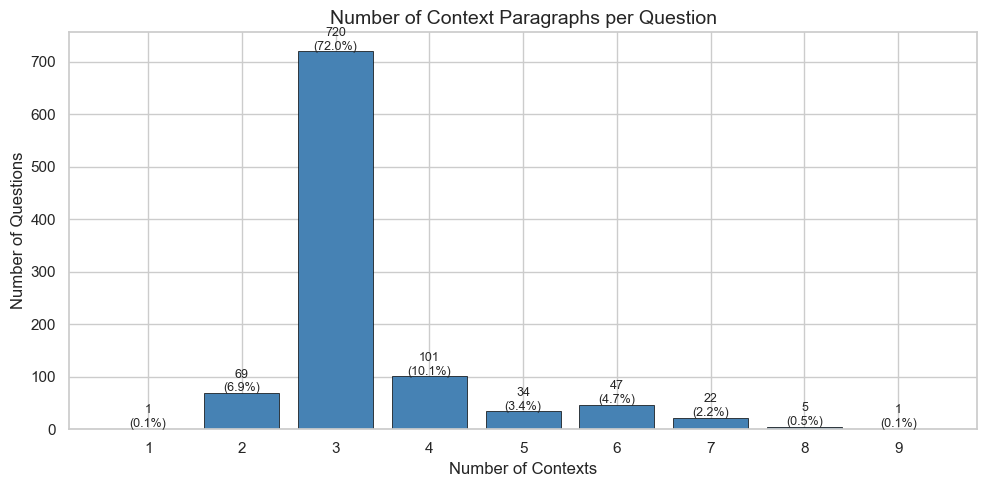

72% have 3 contexts, ORACLE retrieval pipeline designed for variable context count


In [6]:
ctx_counts = df['n_ctx'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(ctx_counts.index, ctx_counts.values,
              color='steelblue', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, ctx_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=9)
ax.set_title('Number of Context Paragraphs per Question', fontsize=14)
ax.set_xlabel('Number of Contexts')
ax.set_ylabel('Number of Questions')
ax.set_xticks(ctx_counts.index)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_context_count.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'72% have 3 contexts, ORACLE retrieval pipeline designed for variable context count')

## 5. Long Answer Length by Label

Maybe answers are longer (mean 306 chars), uncertainty requires more explanation.

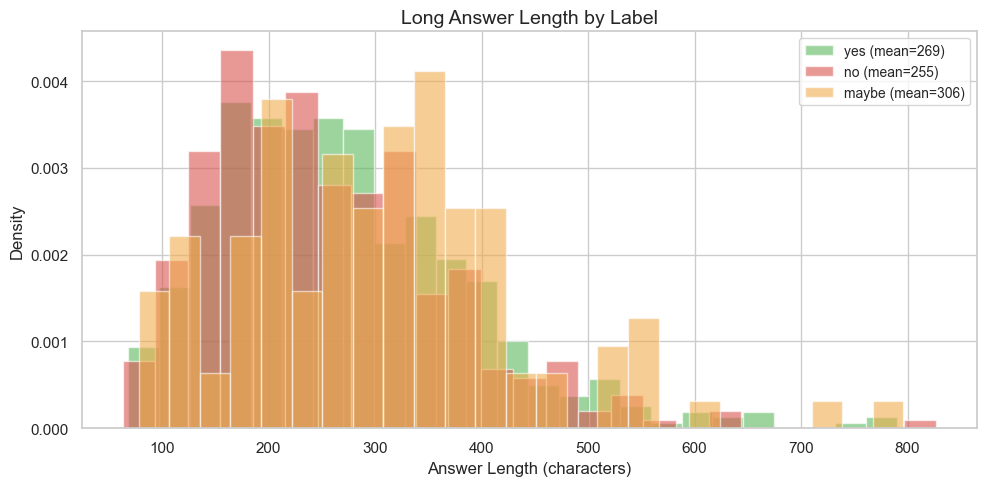

Maybe answers longest (306 chars), uncertainty requires more nuanced explanation


In [7]:
fig, ax = plt.subplots(figsize=(10,5))
for label in ['yes','no','maybe']:
    subset = df[df['label']==label]['ans_len']
    ax.hist(subset, bins=25, alpha=0.6, color=LABEL_COLORS[label],
            label=f'{label} (mean={subset.mean():.0f})', density=True)
ax.set_title('Long Answer Length by Label', fontsize=14)
ax.set_xlabel('Answer Length (characters)')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_answer_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Maybe answers longest (306 chars), uncertainty requires more nuanced explanation')

## 6. Top 15 MeSH Terms

MeSH terms enable topic-stratified retrieval evaluation in ORACLE Stage 2.

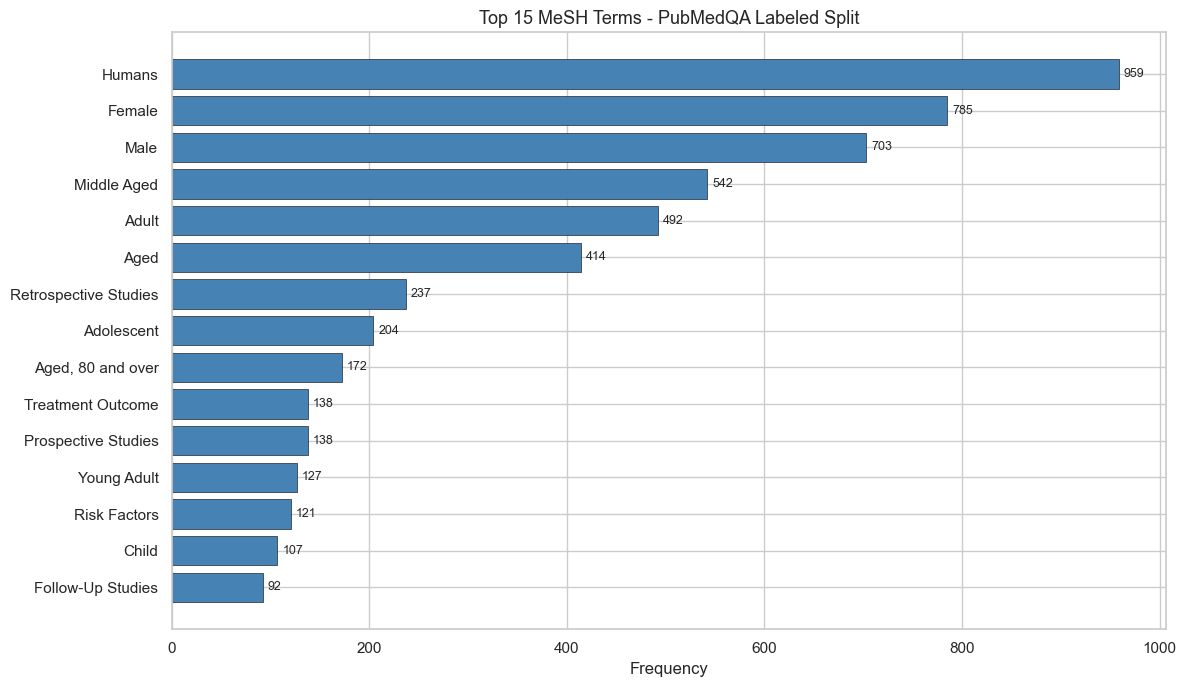

Humans (n=959), Female (n=785), Male (n=703) dominate, broad human health coverage


In [8]:
all_meshes = [m for meshes in df['meshes'] for m in meshes]
mesh_counts = pd.Series(all_meshes).value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(mesh_counts.index[::-1], mesh_counts.values[::-1],
        color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Top 15 MeSH Terms - PubMedQA Labeled Split', fontsize=13)
ax.set_xlabel('Frequency')
for i, val in enumerate(mesh_counts.values[::-1]):
    ax.text(val+5, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_mesh_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Humans (n=959), Female (n=785), Male (n=703) dominate, broad human health coverage')

## 7. Reasoning Required vs Free Predictions

Reasoning-required model predicts more yes (61.4%) than reasoning-free (55.0%). 70.1% agreement between modes.

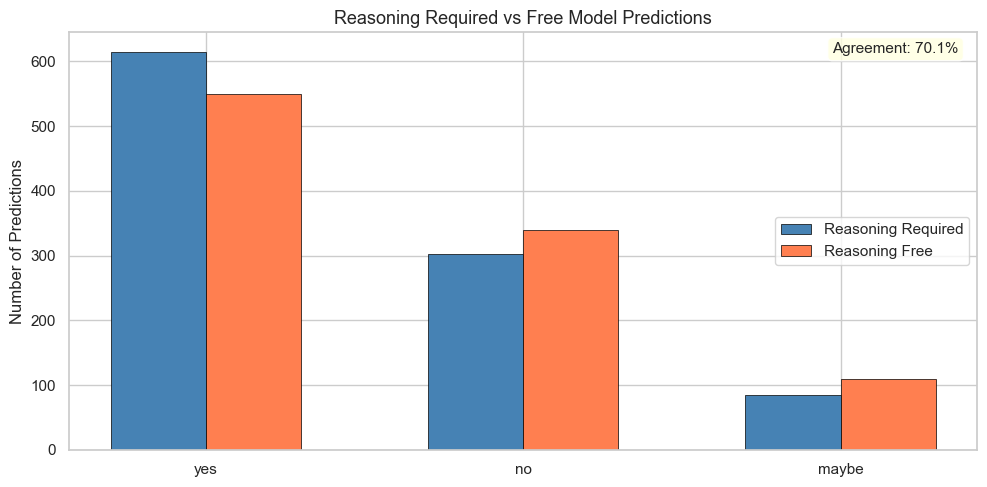

In [9]:
labels_order = ['yes','no','maybe']
req_counts = df['reasoning_req'].value_counts()
free_counts = df['reasoning_free'].value_counts()

x = range(len(labels_order))
width = 0.3
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([i-width/2 for i in x], [req_counts.get(l,0) for l in labels_order],
       width, label='Reasoning Required', color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar([i+width/2 for i in x], [free_counts.get(l,0) for l in labels_order],
       width, label='Reasoning Free', color='coral', edgecolor='black', linewidth=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_order)
ax.set_title('Reasoning Required vs Free Model Predictions', fontsize=13)
ax.set_ylabel('Number of Predictions')
ax.legend()
agree = (df['reasoning_req'] == df['reasoning_free']).mean()
ax.text(0.98, 0.95, f'Agreement: {agree:.1%}', transform=ax.transAxes,
        fontsize=11, ha='right', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_reasoning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Label vs Context Length

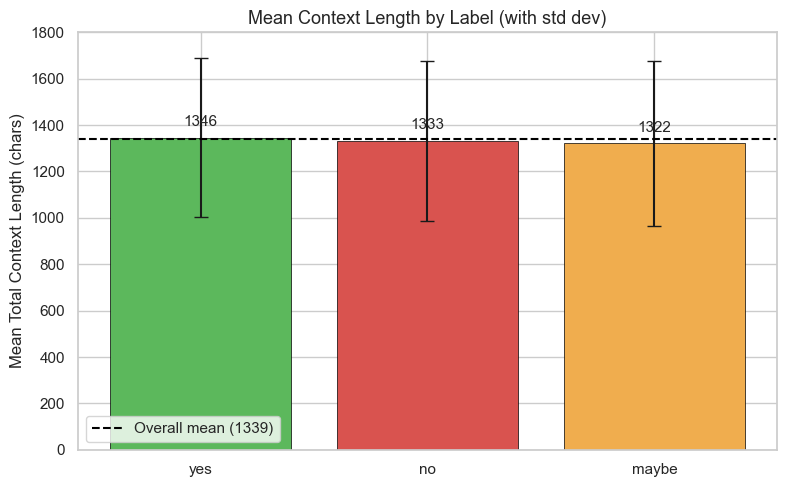

Context length nearly identical across labels, no length bias


In [10]:
ctx_by_label = df.groupby('label')['ctx_len'].agg(['mean','std']).reindex(['yes','no','maybe'])

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(ctx_by_label.index, ctx_by_label['mean'],
              color=[LABEL_COLORS[l] for l in ctx_by_label.index],
              edgecolor='black', linewidth=0.5,
              yerr=ctx_by_label['std'], capsize=5)
ax.axhline(y=df['ctx_len'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall mean ({df["ctx_len"].mean():.0f})')
ax.set_title('Mean Context Length by Label (with std dev)', fontsize=13)
ax.set_ylabel('Mean Total Context Length (chars)')
ax.set_ylim(0, 1800)
ax.legend()
for bar, (label, row) in zip(bars, ctx_by_label.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{row["mean"]:.0f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_label_context.png', dpi=150, bbox_inches='tight')
plt.show()
print('Context length nearly identical across labels, no length bias')

## 9. Reasoning Agreement, Confusion Matrix

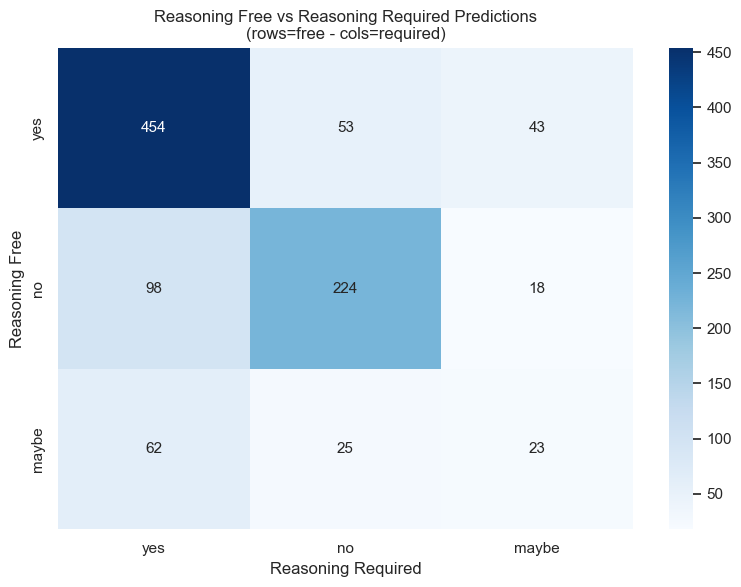

Overall agreement: 70.1%


In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

labels_order = ['yes','no','maybe']
cm = confusion_matrix(df['reasoning_free'], df['reasoning_req'], labels=labels_order)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=labels_order, yticklabels=labels_order)
ax.set_title('Reasoning Free vs Reasoning Required Predictions\n(rows=free - cols=required)', fontsize=12)
ax.set_xlabel('Reasoning Required')
ax.set_ylabel('Reasoning Free')
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_reasoning_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
agree = (df['reasoning_req'] == df['reasoning_free']).mean()
print(f'Overall agreement: {agree:.1%}')

## 10. PubMedQA Split Sizes, Full Dataset Overview

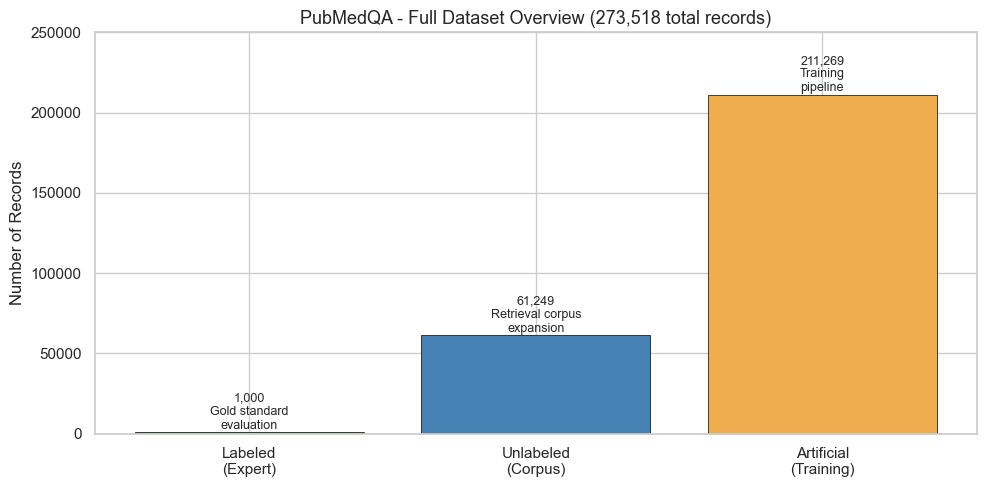

Total: 273,518 records across 3 splits
ORACLE EDA focuses on labeled split, evaluation gold standard


In [12]:
splits = ['Labeled\n(Expert)', 'Unlabeled\n(Corpus)', 'Artificial\n(Training)']
sizes = [1000, 61249, 211269]
purposes = ['Gold standard\nevaluation', 'Retrieval corpus\nexpansion', 'Training\npipeline']

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#5cb85c','steelblue','#f0ad4e']
bars = ax.bar(splits, sizes, color=colors, edgecolor='black', linewidth=0.5)
for bar, val, purpose in zip(bars, sizes, purposes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}\n{purpose}', ha='center', fontsize=9)
ax.set_title('PubMedQA - Full Dataset Overview (273,518 total records)', fontsize=13)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, 250000)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {sum(sizes):,} records across 3 splits')
print('ORACLE EDA focuses on labeled split, evaluation gold standard')

## 11. Baseline Model Accuracy vs Ground Truth

Reasoning free (91.6%) massively outperforms reasoning required (78.1%). Maybe label is hardest for both modes. **ORACLE Stage 2 must beat 91.6% baseline.**

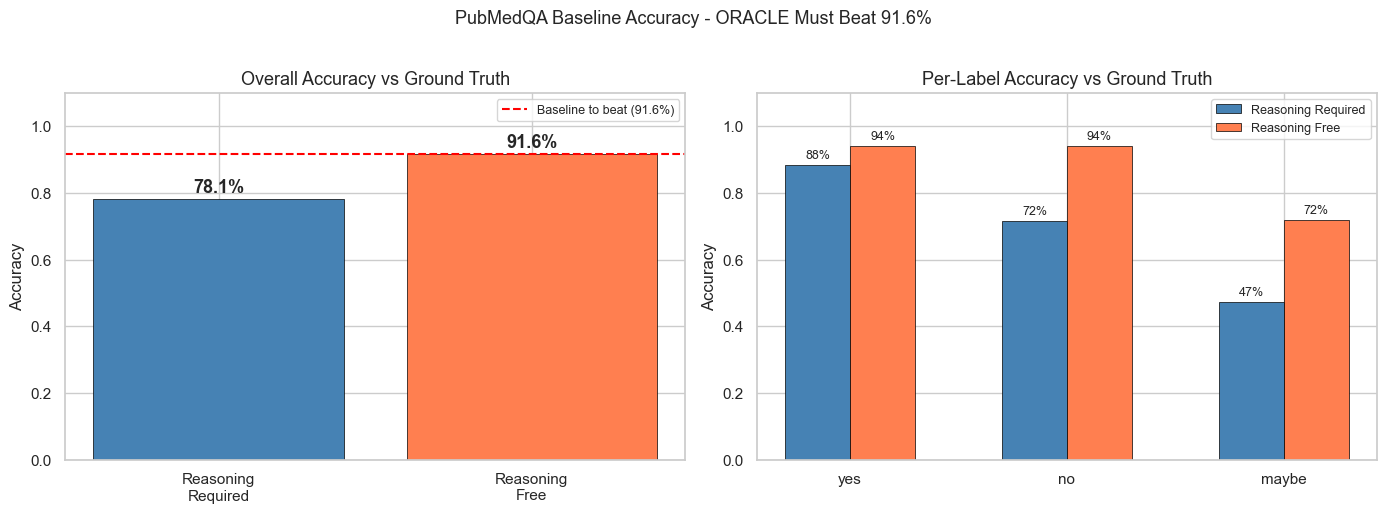

Reasoning free: 91.6% | Reasoning required: 78.1%
Maybe label hardest, req 47.3%, free 71.8%


In [13]:
req_acc = (df['reasoning_req'] == df['label']).mean()
free_acc = (df['reasoning_free'] == df['label']).mean()

labels_order = ['yes','no','maybe']
req_per = [(df[df['label']==l]['reasoning_req']==l).mean() for l in labels_order]
free_per = [(df[df['label']==l]['reasoning_free']==l).mean() for l in labels_order]

x = range(len(labels_order))
width = 0.3
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

# Overall accuracy
ax1.bar(['Reasoning\nRequired','Reasoning\nFree'], [req_acc, free_acc],
        color=['steelblue','coral'], edgecolor='black', linewidth=0.5)
ax1.set_title('Overall Accuracy vs Ground Truth', fontsize=13)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.916, color='red', linestyle='--', linewidth=1.5, label='Baseline to beat (91.6%)')
ax1.legend(fontsize=9)
for i, (name, val) in enumerate(zip(['Req','Free'], [req_acc, free_acc])):
    ax1.text(i, val+0.02, f'{val:.1%}', ha='center', fontsize=13, fontweight='bold')

# Per-label accuracy
ax2.bar([i-width/2 for i in x], req_per, width, label='Reasoning Required',
        color='steelblue', edgecolor='black', linewidth=0.5)
ax2.bar([i+width/2 for i in x], free_per, width, label='Reasoning Free',
        color='coral', edgecolor='black', linewidth=0.5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels_order)
ax2.set_title('Per-Label Accuracy vs Ground Truth', fontsize=13)
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for i, (r, f) in enumerate(zip(req_per, free_per)):
    ax2.text(i-width/2, r+0.02, f'{r:.0%}', ha='center', fontsize=9)
    ax2.text(i+width/2, f+0.02, f'{f:.0%}', ha='center', fontsize=9)

plt.suptitle('PubMedQA Baseline Accuracy - ORACLE Must Beat 91.6%', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/pubmedqa_baseline_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Reasoning free: {free_acc:.1%} | Reasoning required: {req_acc:.1%}')
print('Maybe label hardest, req 47.3%, free 71.8%')

## 12. Key Observations

**Yes-biased dataset (55.2%):** Most biomedical hypotheses are confirmed in literature. This reflects publication bias, studies confirming hypotheses are more likely published.

**Context structure:** 72% of questions have exactly 3 context paragraphs. Mean total context 1,339 chars. Near-zero label-context correlation (r=0.018).

**Maybe answers longest (306 chars):** Uncertainty requires more nuanced explanation than definitive yes (269 chars) or no (255 chars) answers.

**Reasoning modes disagree 30%:** Reasoning-required model predicts more yes (61.4%) than reasoning-free (55.0%). 70.1% agreement, ORACLE evaluates both.

**MeSH coverage:** Humans (96%), Female (78.5%), Male (70.3%), broad human health coverage. MeSH terms enable topic-stratified retrieval evaluation in ORACLE Stage 2.

**Research-facing limitation:** Questions written by researchers for researchers. ORACLE uses PubMedQA for retrieval baseline, then Consumer Health QA and PLABA for patient accessibility evaluation.